In [ ]:
#Ai in Health care Lab 2

#E23CSEU1558

In [1]:
# ============================================================
# CELL 1: INSTALL REQUIRED LIBRARIES
# ============================================================

!pip -q install pandas numpy matplotlib seaborn scikit-learn openpyxl

In [2]:
# ============================================================
# CELL 2: IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# ============================================================
# CELL 3: DATASET ACQUISITION
# ============================================================

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00519/heart_failure_clinical_records_dataset.csv"

df = pd.read_csv(url)

print("Dataset downloaded successfully!")
print("Shape of dataset:", df.shape)

Dataset downloaded successfully!
Shape of dataset: (299, 13)


In [ ]:
# ============================================================
# CELL 4: LOAD AND DISPLAY DATA
# ============================================================

display(df.head())

In [5]:
# ============================================================
# CELL 4: LOAD AND DISPLAY DATA
# ============================================================

display(df.head())

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [6]:
# ============================================================
# CELL 5: SUMMARIZE DATASET
# ============================================================

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Number of rows: 299
Number of columns: 13

Data Types:
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

Missing Values:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [7]:
# ============================================================
# CELL 6: DATASET INFORMATION
# ============================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [8]:
# ============================================================
# CELL 7: BASIC STATISTICS
# ============================================================

display(df.describe())

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


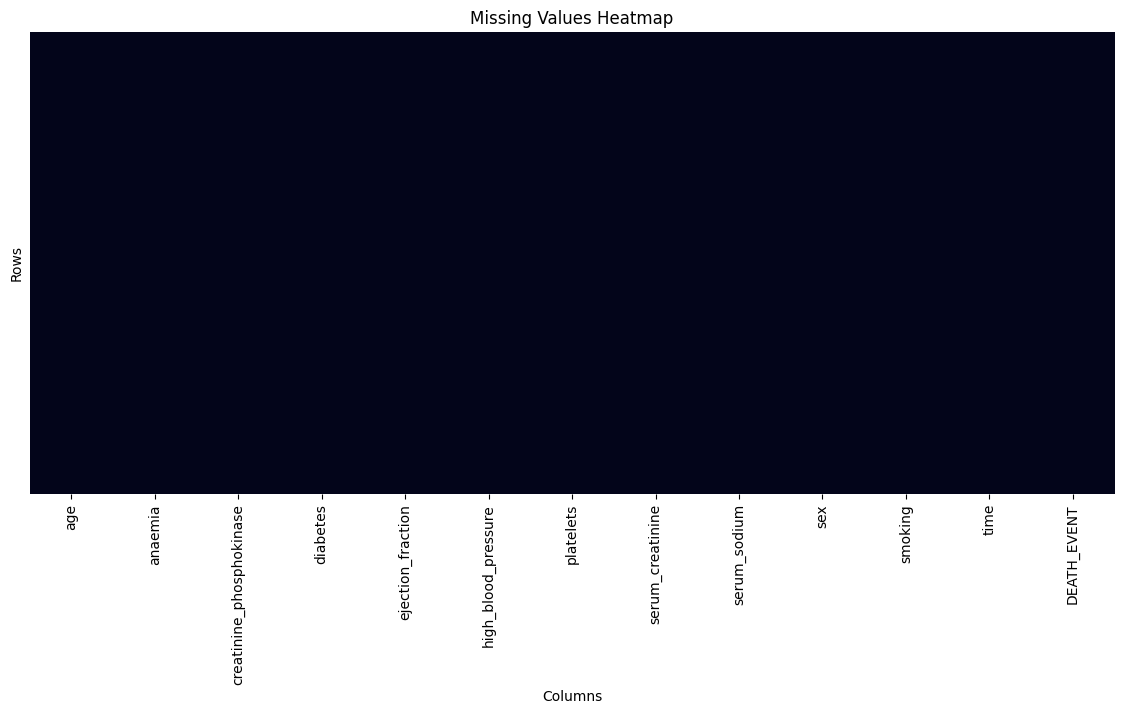

In [9]:
# ============================================================
# CELL 8: MISSING VALUE HEATMAP
# ============================================================

plt.figure(figsize=(14, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")

plt.show()

In [10]:
# ============================================================
# CELL 9: IDENTIFY COLUMN TYPES
# ============================================================

numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Numerical Columns:")
print(numerical_columns)

Numerical Columns:
['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT']


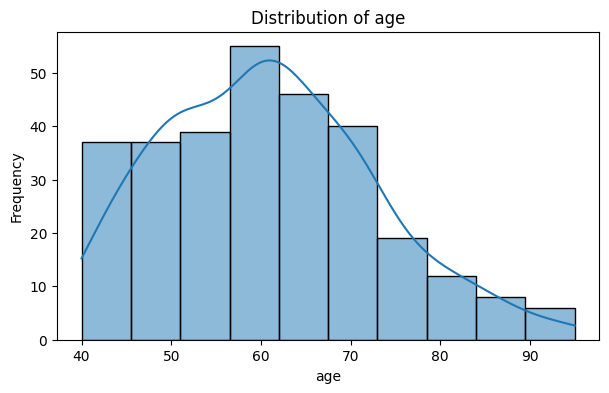

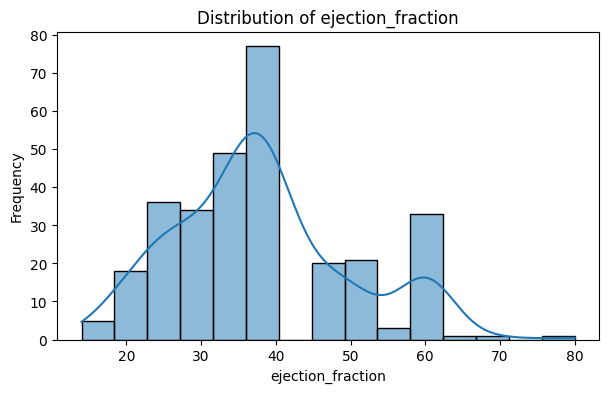

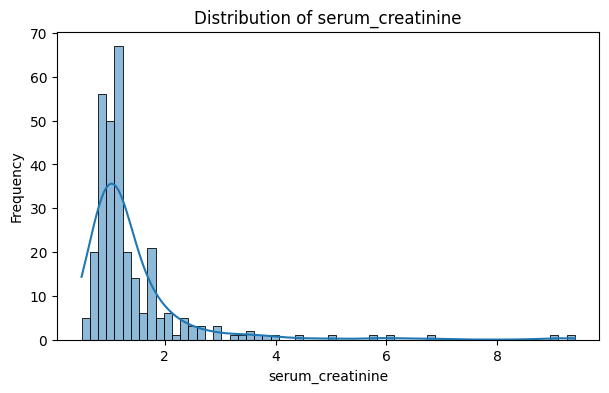

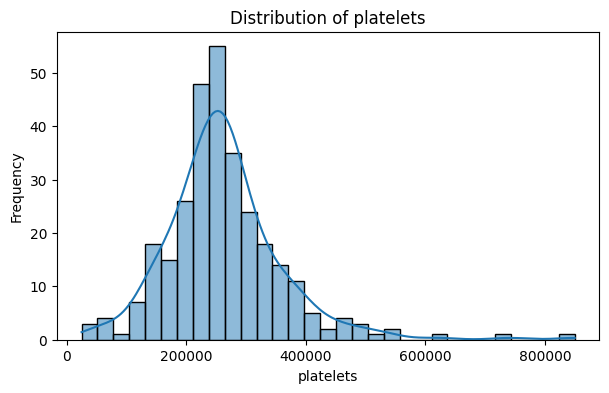

In [11]:
# ============================================================
# CELL 10: HISTOGRAMS
# ============================================================

features_to_plot = [
    "age",
    "ejection_fraction",
    "serum_creatinine",
    "platelets"
]

for feature in features_to_plot:

    plt.figure(figsize=(7, 4))

    sns.histplot(
        df[feature],
        kde=True
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.show()

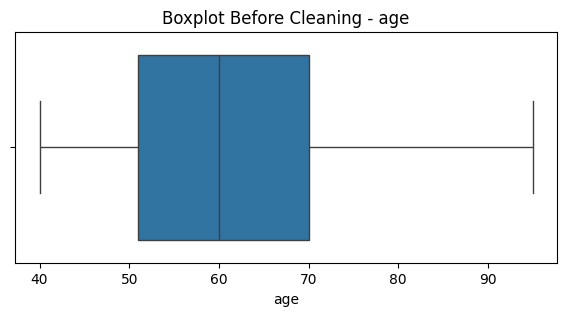

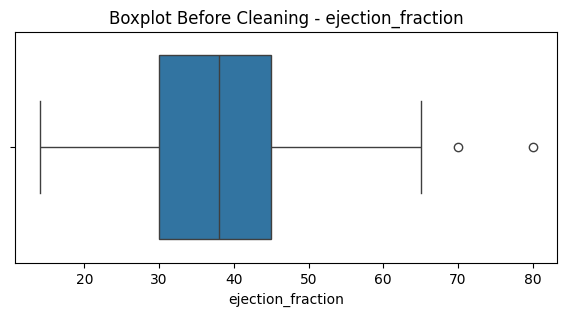

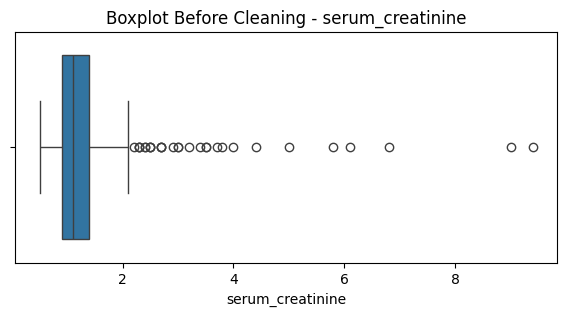

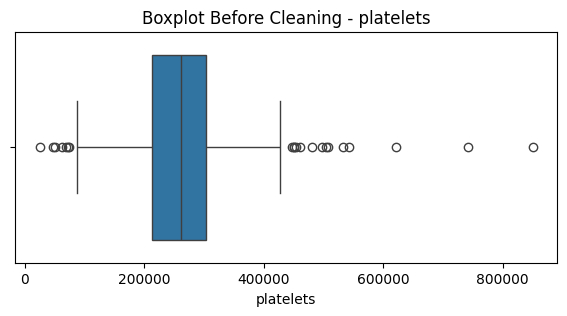

In [12]:
# ============================================================
# CELL 11: BOXPLOTS BEFORE CLEANING
# ============================================================

for feature in features_to_plot:

    plt.figure(figsize=(7, 3))

    sns.boxplot(
        x=df[feature]
    )

    plt.title(f"Boxplot Before Cleaning - {feature}")
    plt.xlabel(feature)

    plt.show()

In [13]:
# ============================================================
# CELL 12: CREATE CLEANING COPY
# ============================================================

df_clean = df.copy()

print("Original shape:", df.shape)
print("Cleaning dataset shape:", df_clean.shape)

Original shape: (299, 13)
Cleaning dataset shape: (299, 13)


In [14]:
# ============================================================
# CELL 13: CREATE SAMPLE MISSING VALUES
# ============================================================

np.random.seed(42)

# Create missing values in numerical columns
missing_rows = np.random.choice(
    df_clean.index,
    size=5,
    replace=False
)

df_clean.loc[missing_rows, "serum_creatinine"] = np.nan

# Create missing values in categorical column
missing_rows_smoking = np.random.choice(
    df_clean.index,
    size=5,
    replace=False
)

df_clean.loc[missing_rows_smoking, "smoking"] = np.nan

print("Missing values introduced for demonstration:")
print(df_clean.isnull().sum())

Missing values introduced for demonstration:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            5
serum_sodium                0
sex                         0
smoking                     5
time                        0
DEATH_EVENT                 0
dtype: int64


In [15]:
# ============================================================
# CELL 14: NUMERICAL IMPUTATION
# ============================================================

numerical_impute_columns = [
    "age",
    "ejection_fraction",
    "serum_creatinine",
    "platelets"
]

for column in numerical_impute_columns:

    median_value = df_clean[column].median()

    df_clean[column] = df_clean[column].fillna(
        median_value
    )

print("Numerical missing values imputed using median.")

Numerical missing values imputed using median.


In [16]:
# ============================================================
# CELL 15: CATEGORICAL IMPUTATION
# ============================================================

categorical_columns = [
    "sex",
    "smoking"
]

for column in categorical_columns:

    mode_value = df_clean[column].mode()[0]

    df_clean[column] = df_clean[column].fillna(
        mode_value
    )

print("Categorical missing values imputed using mode.")

Categorical missing values imputed using mode.


In [17]:
# ============================================================
# CELL 16: VERIFY IMPUTATION
# ============================================================

print("Missing values after imputation:")
print(df_clean.isnull().sum())

Missing values after imputation:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [18]:
# ============================================================
# CELL 17: REMOVE OUTLIERS USING IQR
# ============================================================

outlier_columns = [
    "age",
    "ejection_fraction",
    "serum_creatinine",
    "platelets"
]

df_no_outliers = df_clean.copy()

for column in outlier_columns:

    Q1 = df_no_outliers[column].quantile(0.25)
    Q3 = df_no_outliers[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df_no_outliers = df_no_outliers[
        (df_no_outliers[column] >= lower_limit) &
        (df_no_outliers[column] <= upper_limit)
    ]

print("Original rows:", len(df_clean))
print("Rows after outlier removal:", len(df_no_outliers))
print("Rows removed:", len(df_clean) - len(df_no_outliers))

Original rows: 299
Rows after outlier removal: 253
Rows removed: 46


In [19]:
# ============================================================
# CELL 18: CHECK INVALID / INCONSISTENT VALUES
# ============================================================

print("Minimum age:", df_no_outliers["age"].min())
print("Minimum ejection fraction:",
      df_no_outliers["ejection_fraction"].min())
print("Minimum serum creatinine:",
      df_no_outliers["serum_creatinine"].min())

# Check for negative age
negative_age_count = (
    df_no_outliers["age"] < 0
).sum()

print("\nNegative age values:", negative_age_count)

# Correct negative ages if any are present
df_no_outliers.loc[
    df_no_outliers["age"] < 0,
    "age"
] = df_no_outliers["age"].median()

print("Invalid age values corrected.")

Minimum age: 40.0
Minimum ejection fraction: 14
Minimum serum creatinine: 0.5

Negative age values: 0
Invalid age values corrected.


In [20]:
# ============================================================
# CELL 19: CREATE AGE_GROUP
# ============================================================

def create_age_group(age):

    if age < 40:
        return "<40"

    elif age <= 60:
        return "40-60"

    else:
        return ">60"


df_no_outliers["age_group"] = (
    df_no_outliers["age"]
    .apply(create_age_group)
)

print("Age group created!")

display(
    df_no_outliers[
        ["age", "age_group"]
    ].head(10)
)

Age group created!


,age,age_group
0,75.0,>60
1,55.0,40-60
2,65.0,>60
3,50.0,40-60
5,90.0,>60
6,75.0,>60
8,65.0,>60
9,80.0,>60
11,62.0,>60
12,45.0,40-60


In [21]:
# ============================================================
# CELL 20: CREATE RISK SCORE
# ============================================================

# Normalize the two features
ef_min = df_no_outliers["ejection_fraction"].min()
ef_max = df_no_outliers["ejection_fraction"].max()

creatinine_min = df_no_outliers["serum_creatinine"].min()
creatinine_max = df_no_outliers["serum_creatinine"].max()

df_no_outliers["ef_normalized"] = (
    (df_no_outliers["ejection_fraction"] - ef_min) /
    (ef_max - ef_min)
)

df_no_outliers["creatinine_normalized"] = (
    (df_no_outliers["serum_creatinine"] - creatinine_min) /
    (creatinine_max - creatinine_min)
)

# Product-based risk score
df_no_outliers["risk_score"] = (
    df_no_outliers["ef_normalized"] *
    df_no_outliers["creatinine_normalized"]
)

print("Risk score created!")

display(
    df_no_outliers[
        [
            "ejection_fraction",
            "serum_creatinine",
            "risk_score"
        ]
    ].head(10)
)

Risk score created!


,ejection_fraction,serum_creatinine,risk_score
0,20,1.9,0.102941
1,38,1.1,0.176471
2,20,1.3,0.058824
3,20,1.9,0.102941
5,40,2.1,0.509804
6,15,1.2,0.008578
8,65,1.5,0.625000
9,35,1.1,0.154412
11,25,0.9,0.053922
12,30,1.1,0.117647


In [22]:
# ============================================================
# CELL 21: ONE-HOT ENCODING
# ============================================================

df_encoded = pd.get_dummies(
    df_no_outliers,
    columns=["sex", "smoking"],
    drop_first=True
)

print("Categorical variables encoded successfully!")

display(df_encoded.head())

Categorical variables encoded successfully!


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,time,DEATH_EVENT,age_group,ef_normalized,creatinine_normalized,risk_score,sex_1,smoking_1.0
0,75.0,0,582,0,20,1,265000.00,1.9,130,4,1,>60,0.117647,0.875,0.102941,True,False
1,55.0,0,7861,0,38,0,263358.03,1.1,136,6,1,40-60,0.470588,0.375,0.176471,True,False
2,65.0,0,146,0,20,0,162000.00,1.3,129,7,1,>60,0.117647,0.500,0.058824,True,True
3,50.0,1,111,0,20,0,210000.00,1.9,137,7,1,40-60,0.117647,0.875,0.102941,True,False
5,90.0,1,47,0,40,1,204000.00,2.1,132,8,1,>60,0.509804,1.000,0.509804,True,True


In [23]:
# ============================================================
# CELL 22: CHECK ENCODED DATA
# ============================================================

print("Columns after encoding:")
print(df_encoded.columns.tolist())

print("\nData types:")
print(df_encoded.dtypes)

Columns after encoding:
['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'time', 'DEATH_EVENT', 'age_group', 'ef_normalized', 'creatinine_normalized', 'risk_score', 'sex_1', 'smoking_1.0']

Data types:
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
time                          int64
DEATH_EVENT                   int64
age_group                    object
ef_normalized               float64
creatinine_normalized       float64
risk_score                  float64
sex_1                          bool
smoking_1.0                    bool
dtype: object


In [24]:
# ============================================================
# CELL 23: NORMALIZE NUMERICAL FEATURES
# ============================================================

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

columns_to_scale = [
    "age",
    "ejection_fraction",
    "serum_creatinine",
    "platelets",
    "serum_sodium",
    "creatinine_phosphokinase",
    "time"
]

df_encoded[columns_to_scale] = scaler.fit_transform(
    df_encoded[columns_to_scale]
)

print("Numerical features normalized to 0-1.")

display(
    df_encoded[columns_to_scale].head()
)

Numerical features normalized to 0-1.


,age,ejection_fraction,serum_creatinine,platelets,serum_sodium,creatinine_phosphokinase,time
0,0.636364,0.117647,0.875,0.539773,0.485714,0.070489,0.000000
1,0.272727,0.470588,0.375,0.535108,0.657143,1.000000,0.007117
2,0.454545,0.117647,0.500,0.247159,0.457143,0.014813,0.010676
3,0.181818,0.117647,0.875,0.383523,0.685714,0.010344,0.010676
5,0.909091,0.509804,1.000,0.366477,0.542857,0.002171,0.014235


In [25]:
# ============================================================
# CELL 24: STATISTICS BEFORE CLEANING
# ============================================================

statistics_before = pd.DataFrame({
    "Mean": df.mean(numeric_only=True),
    "Median": df.median(numeric_only=True),
    "Standard Deviation": df.std(numeric_only=True)
})

display(statistics_before)

,Mean,Median,Standard Deviation
age,60.833893,60.0,11.894809
anaemia,0.431438,0.0,0.496107
creatinine_phosphokinase,581.839465,250.0,970.287881
diabetes,0.418060,0.0,0.494067
ejection_fraction,38.083612,38.0,11.834841
high_blood_pressure,0.351171,0.0,0.478136
platelets,263358.029264,262000.0,97804.236869
serum_creatinine,1.393880,1.1,1.034510
serum_sodium,136.625418,137.0,4.412477
sex,0.648829,1.0,0.478136


In [26]:
# ============================================================
# CELL 25: STATISTICS AFTER CLEANING
# ============================================================

statistics_after = pd.DataFrame({
    "Mean": df_no_outliers.select_dtypes(
        include=np.number
    ).mean(),

    "Median": df_no_outliers.select_dtypes(
        include=np.number
    ).median(),

    "Standard Deviation": df_no_outliers.select_dtypes(
        include=np.number
    ).std()
})

display(statistics_after)

,Mean,Median,Standard Deviation
age,60.345194,60.000000,11.933470
anaemia,0.442688,0.000000,0.497689
creatinine_phosphokinase,598.296443,249.000000,1006.394978
diabetes,0.415020,0.000000,0.493702
ejection_fraction,37.909091,38.000000,11.497914
high_blood_pressure,0.371542,0.000000,0.484175
platelets,255443.615375,263000.000000,69213.693545
serum_creatinine,1.129486,1.100000,0.333374
serum_sodium,136.913043,137.000000,4.213587
sex,0.656126,1.000000,0.475941


In [27]:
# ============================================================
# CELL 26: BEFORE vs AFTER COMPARISON
# ============================================================

comparison = pd.DataFrame({
    "Before Mean": df.mean(numeric_only=True),
    "After Mean": df_no_outliers.mean(numeric_only=True),

    "Before Median": df.median(numeric_only=True),
    "After Median": df_no_outliers.median(numeric_only=True),

    "Before Std": df.std(numeric_only=True),
    "After Std": df_no_outliers.std(numeric_only=True)
})

display(comparison)

,Before Mean,After Mean,Before Median,After Median,Before Std,After Std
DEATH_EVENT,0.321070,0.284585,0.0,0.000000,0.467670,0.452111
age,60.833893,60.345194,60.0,60.000000,11.894809,11.933470
anaemia,0.431438,0.442688,0.0,0.000000,0.496107,0.497689
creatinine_normalized,NaN,0.393429,NaN,0.375000,NaN,0.208359
creatinine_phosphokinase,581.839465,598.296443,250.0,249.000000,970.287881,1006.394978
diabetes,0.418060,0.415020,0.0,0.000000,0.494067,0.493702
ef_normalized,NaN,0.468806,NaN,0.470588,NaN,0.225449
ejection_fraction,38.083612,37.909091,38.0,38.000000,11.834841,11.497914
high_blood_pressure,0.351171,0.371542,0.0,0.000000,0.478136,0.484175
platelets,263358.029264,255443.615375,262000.0,263000.000000,97804.236869,69213.693545


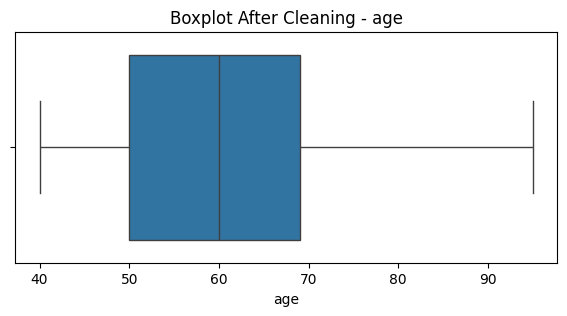

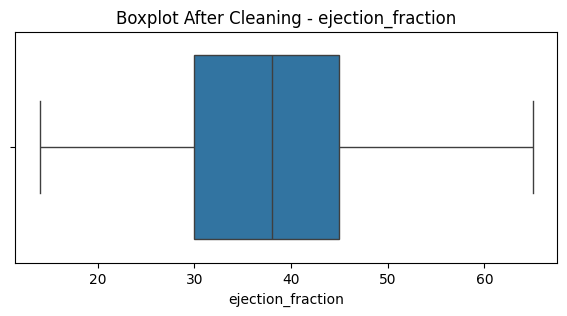

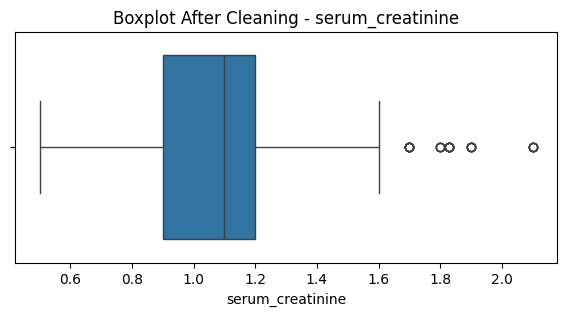

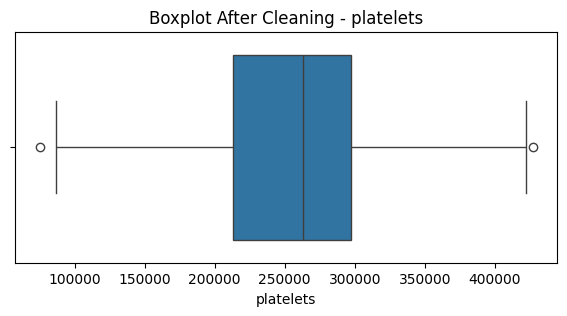

In [28]:
# ============================================================
# CELL 27: BOX PLOTS AFTER CLEANING
# ============================================================

for feature in features_to_plot:

    plt.figure(figsize=(7, 3))

    sns.boxplot(
        x=df_no_outliers[feature]
    )

    plt.title(
        f"Boxplot After Cleaning - {feature}"
    )

    plt.xlabel(feature)

    plt.show()

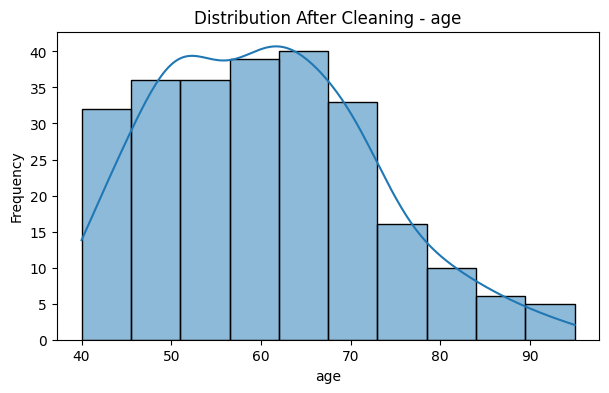

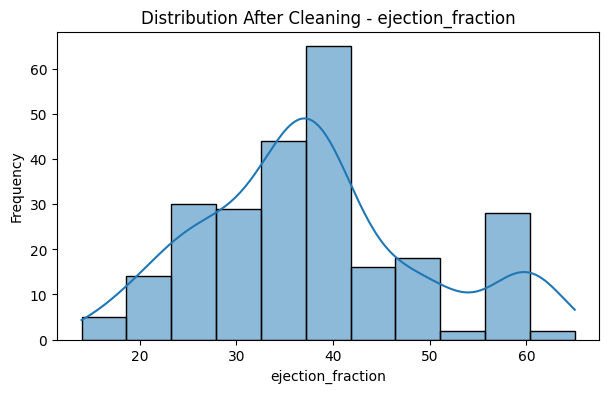

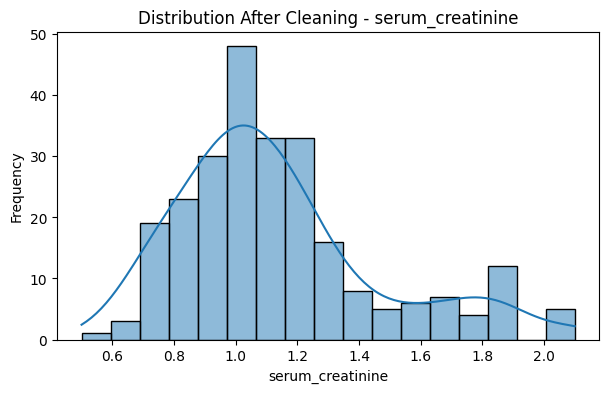

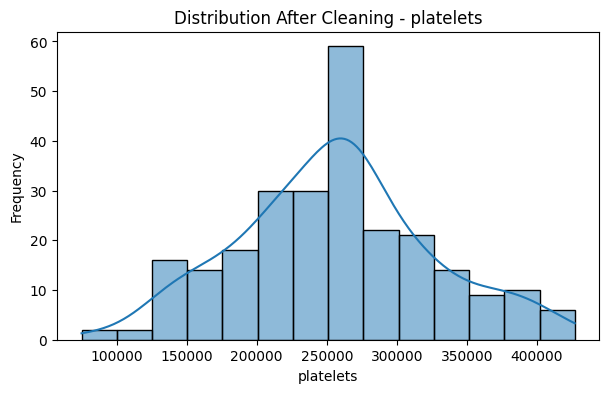

In [29]:
# ============================================================
# CELL 28: HISTOGRAMS AFTER CLEANING
# ============================================================

for feature in features_to_plot:

    plt.figure(figsize=(7, 4))

    sns.histplot(
        df_no_outliers[feature],
        kde=True
    )

    plt.title(
        f"Distribution After Cleaning - {feature}"
    )

    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.show()

In [30]:
# ============================================================
# CELL 29: FINAL MISSING VALUE CHECK
# ============================================================

print("Final missing value count:")
print(df_encoded.isnull().sum())

total_missing = df_encoded.isnull().sum().sum()

print("\nTotal missing values:", total_missing)

if total_missing == 0:
    print("✓ Cleaning successful - No missing values remain.")
else:
    print("⚠ Some missing values still remain.")

Final missing value count:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
time                        0
DEATH_EVENT                 0
age_group                   0
ef_normalized               0
creatinine_normalized       0
risk_score                  0
sex_1                       0
smoking_1.0                 0
dtype: int64

Total missing values: 0
✓ Cleaning successful - No missing values remain.


In [31]:
# ============================================================
# CELL 30: FINAL CLEANED DATASET
# ============================================================

print("Final dataset shape:", df_encoded.shape)

display(df_encoded.head())

print("\nFinal columns:")
print(df_encoded.columns.tolist())

Final dataset shape: (253, 17)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,time,DEATH_EVENT,age_group,ef_normalized,creatinine_normalized,risk_score,sex_1,smoking_1.0
0,0.636364,0,0.070489,0,0.117647,1,0.539773,0.875,0.485714,0.000000,1,>60,0.117647,0.875,0.102941,True,False
1,0.272727,0,1.000000,0,0.470588,0,0.535108,0.375,0.657143,0.007117,1,40-60,0.470588,0.375,0.176471,True,False
2,0.454545,0,0.014813,0,0.117647,0,0.247159,0.500,0.457143,0.010676,1,>60,0.117647,0.500,0.058824,True,True
3,0.181818,1,0.010344,0,0.117647,0,0.383523,0.875,0.685714,0.010676,1,40-60,0.117647,0.875,0.102941,True,False
5,0.909091,1,0.002171,0,0.509804,1,0.366477,1.000,0.542857,0.014235,1,>60,0.509804,1.000,0.509804,True,True



Final columns:
['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'time', 'DEATH_EVENT', 'age_group', 'ef_normalized', 'creatinine_normalized', 'risk_score', 'sex_1', 'smoking_1.0']


In [32]:
# ============================================================
# CELL 31: EXPORT CLEANED DATA
# ============================================================

output_file = "heart_failure_cleaned_dataset.csv"

df_encoded.to_csv(
    output_file,
    index=False
)

print(
    f"Cleaned dataset saved as: {output_file}"
)

Cleaned dataset saved as: heart_failure_cleaned_dataset.csv


In [33]:
# ============================================================
# CELL 32: FINAL EXPERIMENT SUMMARY
# ============================================================

print("=" * 65)
print("        LAB ASSIGNMENT - 2 COMPLETED")
print("=" * 65)

print("\n1. Dataset Acquisition")
print("   ✓ Heart Failure Clinical Records Dataset downloaded")

print("\n2. Dataset Loading")
print("   ✓ Dataset loaded using Pandas")
print("   ✓ First 5 rows displayed")

print("\n3. Dataset Summary")
print("   ✓ Rows, columns and data types inspected")
print("   ✓ Missing values checked")

print("\n4. Missing Value Visualization")
print("   ✓ Seaborn heatmap generated")

print("\n5. Distribution Analysis")
print("   ✓ Histograms and boxplots generated")

print("\n6. Missing Value Imputation")
print("   ✓ Numerical values → Median")
print("   ✓ Categorical values → Mode")

print("\n7. Outlier Removal")
print("   ✓ IQR method applied")

print("\n8. Data Consistency")
print("   ✓ Invalid negative age values checked/corrected")

print("\n9. Feature Engineering")
print("   ✓ age_group created")
print("   ✓ risk_score created")

print("\n10. Categorical Encoding")
print("   ✓ One-hot encoding applied")

print("\n11. Feature Normalization")
print("   ✓ MinMaxScaler applied (0-1)")

print("\n12. Summary Statistics")
print("   ✓ Mean, median and standard deviation calculated")

print("\n13. Cleaning Validation")
print("   ✓ Post-cleaning plots generated")

print("\n14. Final Missing Value Check")
print("   ✓ Missing values verified")

print("\n" + "=" * 65)
print("             EXPERIMENT SUCCESSFULLY COMPLETED")
print("=" * 65)

        LAB ASSIGNMENT - 2 COMPLETED

1. Dataset Acquisition
   ✓ Heart Failure Clinical Records Dataset downloaded

2. Dataset Loading
   ✓ Dataset loaded using Pandas
   ✓ First 5 rows displayed

3. Dataset Summary
   ✓ Rows, columns and data types inspected
   ✓ Missing values checked

4. Missing Value Visualization
   ✓ Seaborn heatmap generated

5. Distribution Analysis
   ✓ Histograms and boxplots generated

6. Missing Value Imputation
   ✓ Numerical values → Median
   ✓ Categorical values → Mode

7. Outlier Removal
   ✓ IQR method applied

8. Data Consistency
   ✓ Invalid negative age values checked/corrected

9. Feature Engineering
   ✓ age_group created
   ✓ risk_score created

10. Categorical Encoding
   ✓ One-hot encoding applied

11. Feature Normalization
   ✓ MinMaxScaler applied (0-1)

12. Summary Statistics
   ✓ Mean, median and standard deviation calculated

13. Cleaning Validation
   ✓ Post-cleaning plots generated

14. Final Missing Value Check
   ✓ Missing values ver